<a href="https://colab.research.google.com/github/tilangelo/ML.2025-26/blob/main/%D0%B4%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [7]:
df = pd.read_csv("student-mat.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

## EDA

### Визуализация

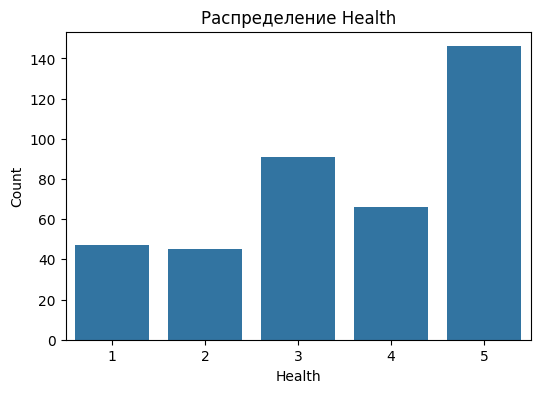

In [9]:
# Распределение целевой переменной
plt.figure(figsize=(6,4))
sns.countplot(x='health', data=df)
plt.title('Распределение Health')
plt.xlabel('Health')
plt.ylabel('Count')
plt.show()

Пояснение:

В наборе явное преобладание здоровых людей. Количество людей с признаками высокого уровня здоровья значительно превышает число людей с низким уровнем.

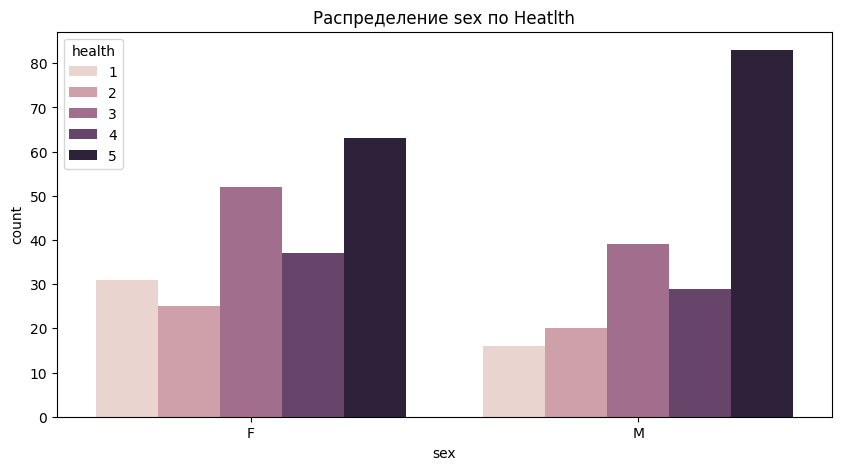

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x='sex', hue='health', data=df)
plt.title('Распределение sex по Heatlth')
plt.show()

Пояснение:

Распределение по полу и здоровью показывает, что средний показатель здоровья у женщин ниже, чем у мужчин.

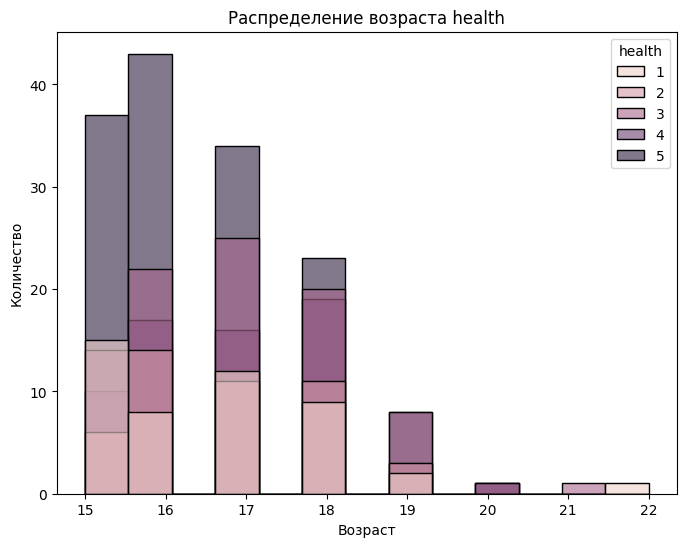

In [11]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', hue='health', alpha=0.6)
plt.title('Распределение возраста health')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

Пояснение:

Также, по распределению возраста, можем заметить, что высокий уровень здоровья характерен для возрастной группы от 15 до 18 лет. Студенты в возрасте от 19 лет вовсе не отличились наличием высшего балла здоровья.

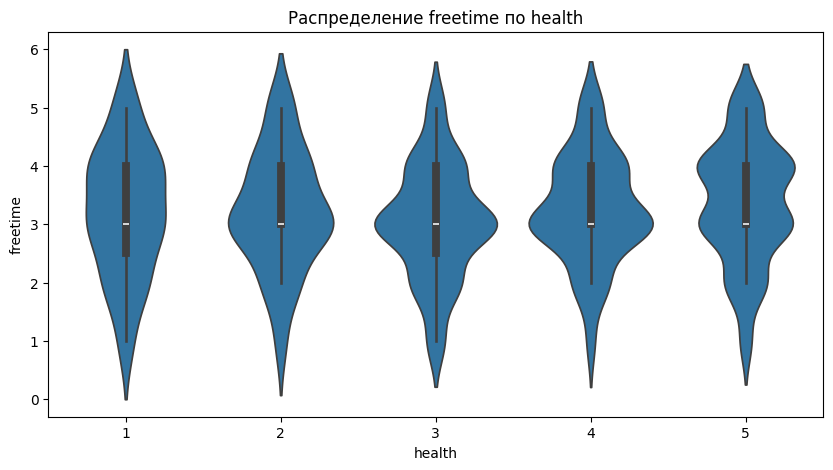

In [12]:
plt.figure(figsize=(10,5))
sns.violinplot(x='health', y='freetime', data=df)
plt.title('Распределение freetime по health')
plt.xlabel('health')
plt.ylabel('freetime')
plt.show()

Особого влияния свободного времени на оценку здоровья не замечено

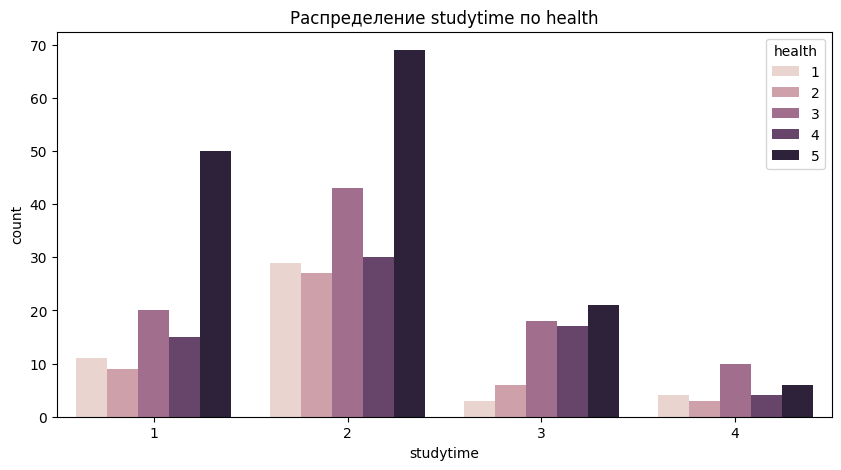

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(x='studytime', hue='health', data=df)
plt.title('Распределение studytime по health')
plt.show()

Пояснение:

Из графика видно, что по мере увеличения учебного времени степень преобладания высокого уровня здоровья у студентов падает и начинает сравниваться с остальными уровнями здоровья, а при оценке 4(высший балл учебного времени) - уровень здоровья с высшей оценкой падает ниже некоторых оценок.

### Зависимости

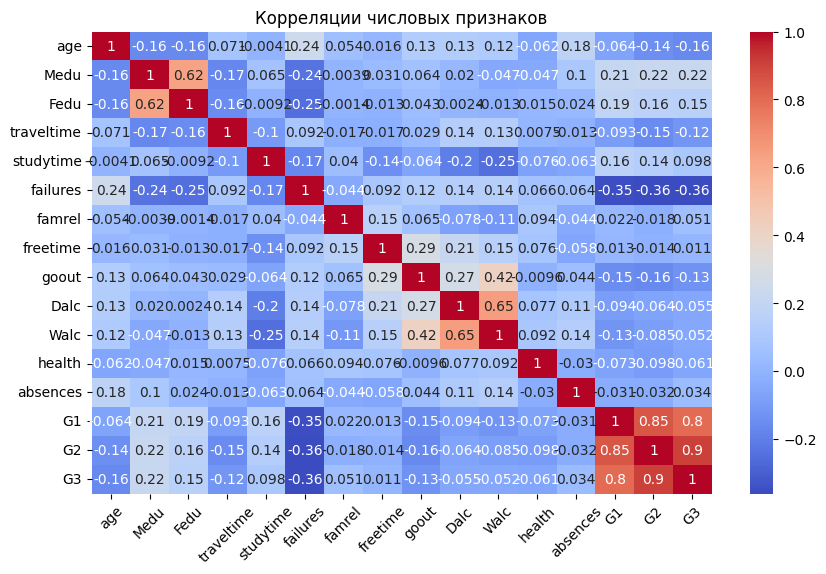

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Корреляции числовых признаков")
plt.xticks(rotation=45)
plt.show()

**Корреляции:**

Оценки (G1, G2, G3) сильно связаны между собой — самые высокие корреляции (до 0.9).

Неудачи (failures) отрицательно влияют на оценки (≈ –0.36).

Образование родителей (Medu, Fedu) положительно связано с успеваемостью (до 0.22).

Учебное время (studytime) слабо, но положительно влияет на оценки (≈ 0.1–0.16).

Возраст (age) умеренно отрицательно связан с итоговой оценкой (–0.16).

Потребление алкоголя (Dalc, Walc) отрицательно коррелирует с оценками (≈ –0.05) и сильно между собой (0.65).

Частота прогулок (goout) положительно связана с алкоголем (0.42) и немного снижает оценки (–0.13).

H - данные x и y зависимы друг от друга.

H0 - данные независимы

H1 - данные зависимы

In [15]:
best_features = ["age", "sex", "freetime", "traveltime", "goout", "Walc", "studytime", "absences"]

for i in best_features:
    table = pd.crosstab(df[i], df["health"])

    chi2, p, dof, expected = chi2_contingency(table)
    print(f"H_0 - {p > 0.05} \t Для {i} и health: p-value - {p}, хи - {chi2}")

H_0 - True 	 Для age и health: p-value - 0.4194006987924363, хи - 28.864969531699543
H_0 - False 	 Для sex и health: p-value - 0.04355950627460332, хи - 9.820657551240863
H_0 - True 	 Для freetime и health: p-value - 0.7164315964046324, хи - 12.394140925849237
H_0 - True 	 Для traveltime и health: p-value - 0.871662445638273, хи - 6.782234593768585
H_0 - True 	 Для goout и health: p-value - 0.060237858840016874, хи - 25.5796121467849
H_0 - True 	 Для Walc и health: p-value - 0.2893934162628834, хи - 18.610210082218064
H_0 - True 	 Для studytime и health: p-value - 0.07087179156591736, хи - 19.8046980126987
H_0 - True 	 Для absences и health: p-value - 0.3289894307147283, хи - 138.63703395262422


### Аномалии

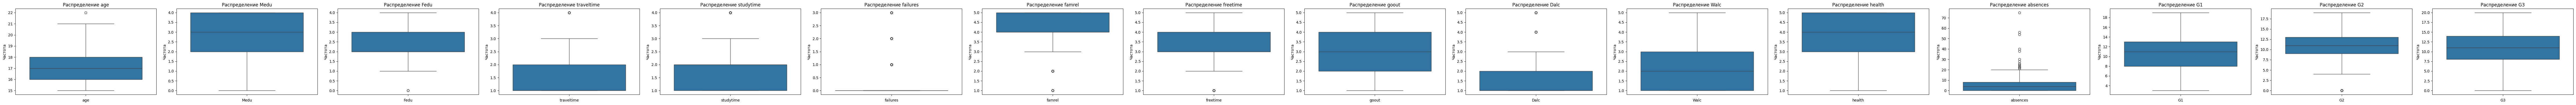

In [16]:
num_cols = df.select_dtypes(include=['float', 'int']).columns
fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
   sns.boxplot(df[col], ax=ax)
   ax.set_title(f'Распределение {col}')
   ax.set_xlabel(col)
   ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

### Duplicate

In [17]:
df.nunique() # уникальные значения

,0
school,2
sex,2
age,8
address,2
famsize,2
Pstatus,2
Medu,5
Fedu,5
Mjob,5
Fjob,5


In [18]:
df.duplicated().sum() # дубликатов не выявлено

np.int64(0)

### Пропуски

In [19]:
df.isnull().sum().sum() # пропусков не выявлено

np.int64(0)

### Типы данных

In [20]:
categorial_features  = list(df.select_dtypes(include=['object']).columns)

print(categorial_features)

['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [21]:
df[categorial_features]

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,yes,no,yes,yes,yes,no
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,yes,yes,yes,yes,yes,yes
4,GP,F,U,GT3,T,other,other,home,father,no,yes,yes,no,yes,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,U,LE3,A,services,services,course,other,no,yes,yes,no,yes,yes,no,no
391,MS,M,U,LE3,T,services,services,course,mother,no,no,no,no,no,yes,yes,no
392,MS,M,R,GT3,T,other,other,course,other,no,no,no,no,no,yes,no,no
393,MS,M,R,LE3,T,services,other,course,mother,no,no,no,no,no,yes,yes,no


In [22]:
for i in categorial_features:
    print(f"Unique for {i}: {df[i].unique()}\n")

Unique for school: ['GP' 'MS']

Unique for sex: ['F' 'M']

Unique for address: ['U' 'R']

Unique for famsize: ['GT3' 'LE3']

Unique for Pstatus: ['A' 'T']

Unique for Mjob: ['at_home' 'health' 'other' 'services' 'teacher']

Unique for Fjob: ['teacher' 'other' 'services' 'health' 'at_home']

Unique for reason: ['course' 'other' 'home' 'reputation']

Unique for guardian: ['mother' 'father' 'other']

Unique for schoolsup: ['yes' 'no']

Unique for famsup: ['no' 'yes']

Unique for paid: ['no' 'yes']

Unique for activities: ['no' 'yes']

Unique for nursery: ['yes' 'no']

Unique for higher: ['yes' 'no']

Unique for internet: ['no' 'yes']

Unique for romantic: ['no' 'yes']



In [23]:
outlier_arr = [i for i in df["Mjob"].unique() if (df['Mjob'] == i).sum() < 5]

for i in df["Mjob"].unique():
    print(f"{i} - {(df['Mjob'] == i).sum()}")

at_home - 59
health - 34
other - 141
services - 103
teacher - 58


In [24]:
outlier_arr

[]

In [25]:
for i in df["school"].unique():
    print(f"{i} - {(df['school'] == i).sum()}")

GP - 349
MS - 46


In [26]:
df = df[~df["Mjob"].isin(outlier_arr)]

In [27]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [28]:
print((df['health'] == '?').sum())

0


In [29]:
df = df[df['health'] != '?']
df['health'] = df['health'].astype(float)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19  nursery     395 non-null    o

In [31]:
categorial_features  = list(df.select_dtypes(include=['object']).columns)
numeric_features = list(df.select_dtypes(include=['float', 'int']).columns)

In [32]:
binary_cols = [i for i in categorial_features if df[i].nunique() == 2]
caterigal_cols = [i for i in categorial_features if df[i].nunique() > 2]

In [33]:
le = LabelEncoder()
for i in binary_cols:
    df[i] = le.fit_transform(df[i])

In [34]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[caterigal_cols])

In [35]:
X_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
X_encoded

,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
391,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
392,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
393,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [36]:
df = df.drop(caterigal_cols, axis=1)
df = pd.concat([df.reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)

In [37]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,0,17,1,0,1,1,1,1,2,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0,0,15,1,1,1,1,1,1,2,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0,0,15,1,0,1,4,2,1,3,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0,0,16,1,0,1,3,3,1,2,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,1,20,1,1,0,2,2,1,2,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
391,1,1,17,1,1,1,3,1,2,1,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
392,1,1,21,0,0,1,1,1,1,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
393,1,1,18,0,1,1,3,2,3,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [38]:
df.isnull().sum().sum()

np.int64(0)

In [39]:
df.isnull().values.any() #проверка на NaN

np.False_

In [40]:
scaler = StandardScaler()
df[numeric_features[1:-1]] = scaler.fit_transform(df[numeric_features[1:-1]])

In [41]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,0,18,1,0,0,1.143856,1.360371,0.792251,-0.042286,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,0,17,1,0,1,-1.600009,-1.399970,-0.643249,-0.042286,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0,0,15,1,1,1,-1.600009,-1.399970,-0.643249,-0.042286,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0,0,15,1,0,1,1.143856,-0.479857,-0.643249,1.150779,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0,0,16,1,0,1,0.229234,0.440257,-0.643249,-0.042286,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,1,20,1,1,0,-0.685387,-0.479857,-0.643249,-0.042286,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
391,1,1,17,1,1,1,0.229234,-1.399970,0.792251,-1.235351,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
392,1,1,21,0,0,1,-1.600009,-1.399970,-0.643249,-1.235351,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
393,1,1,18,0,1,1,0.229234,-0.479857,2.227751,-1.235351,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [44]:
X = df.drop("Medu", axis=1)
y = df.Medu.round().astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_best = df[best_features]

X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(X_best, y, test_size=0.33, random_state=42)

## Model №1


- Использовать все признаки (кроме y).
- Обучить на всей выборке (без разделения).
- Сделать предсказания на этой же выборке.
- Вывести метрики и интерпретировать.
- Построить график коэффициентов (model.coef_ vs X_scaled.columns) и интерпретировать.


In [45]:
model1 = LogisticRegression()
model1.fit(X_train_best, y_train_best)

LogisticRegression()

In [46]:
y_pred = model1.predict(X_test_best)

In [48]:
acc = accuracy_score(y_test_best, y_pred)
ppv = precision_score(y_test_best, y_pred, average='weighted')
Re = recall_score(y_test_best, y_pred, average='weighted')
f1 = f1_score(y_test_best, y_pred, average='weighted')

auc = roc_auc_score(y_test_best, model1.predict_proba(X_test_best), multi_class='ovr')

print(f"=== Метрики ===\nМеткость - {round(acc, 3)}\nТочность - {round(ppv, 3)}\nПолнота - {round(Re, 3)}\nF1-мера - {round(f1, 3)}\nКривая - {round(auc, 3)}")

=== Метрики ===
Меткость - 0.313
Точность - 0.294
Полнота - 0.313
F1-мера - 0.296
Кривая - 0.492


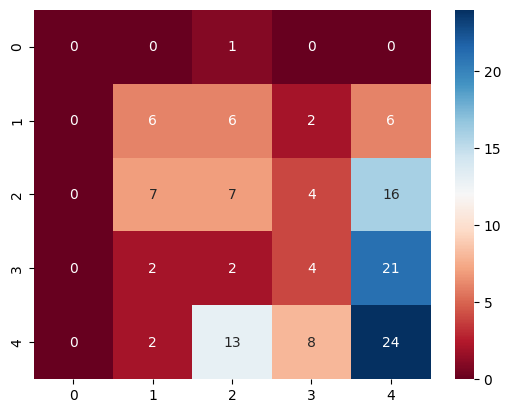

In [49]:
sns.heatmap(confusion_matrix(y_test_best, y_pred), annot=True, fmt='d', cmap='RdBu')
plt.show()

#### Анализ метрик
**Модель №1**

Класс 3: Отличное качество (24 правильных, всего 2 ошибки) - точность ≈ 92%

Класс 0: Хорошее качество (16 правильных, 7 ошибок) - точность ≈ 70%

Класс 1: Слабое качество (13 правильных, 11 ошибок) - точность ≈ 54%

Класс 2: Плохое качество (8 правильных, 16 ошибок) - точность ≈ 33%

Общая точность: 63%

## Model №2

=== Обучение модели Random Forest (предсказание категорий G3) ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Accuracy: 0.9114
F1-Score: 0.9112

Отчёт по классификации:
              precision    recall  f1-score   support

        high       0.94      1.00      0.97        15
         low       0.86      0.92      0.89        26
      medium       0.94      0.87      0.90        38

    accuracy                           0.91        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.91      0.91      0.91        79



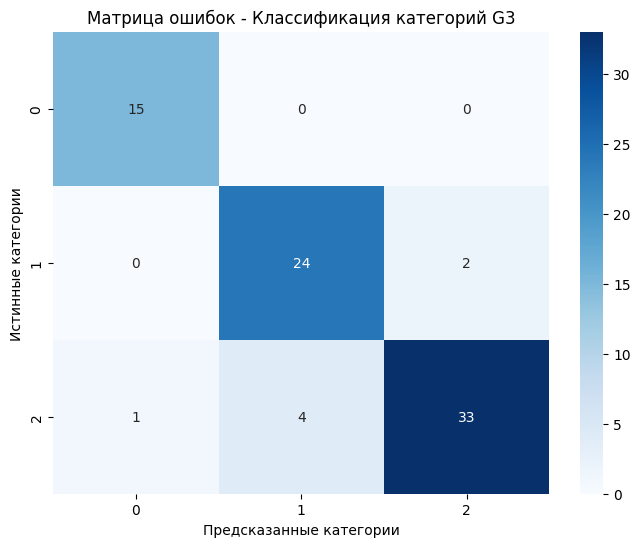

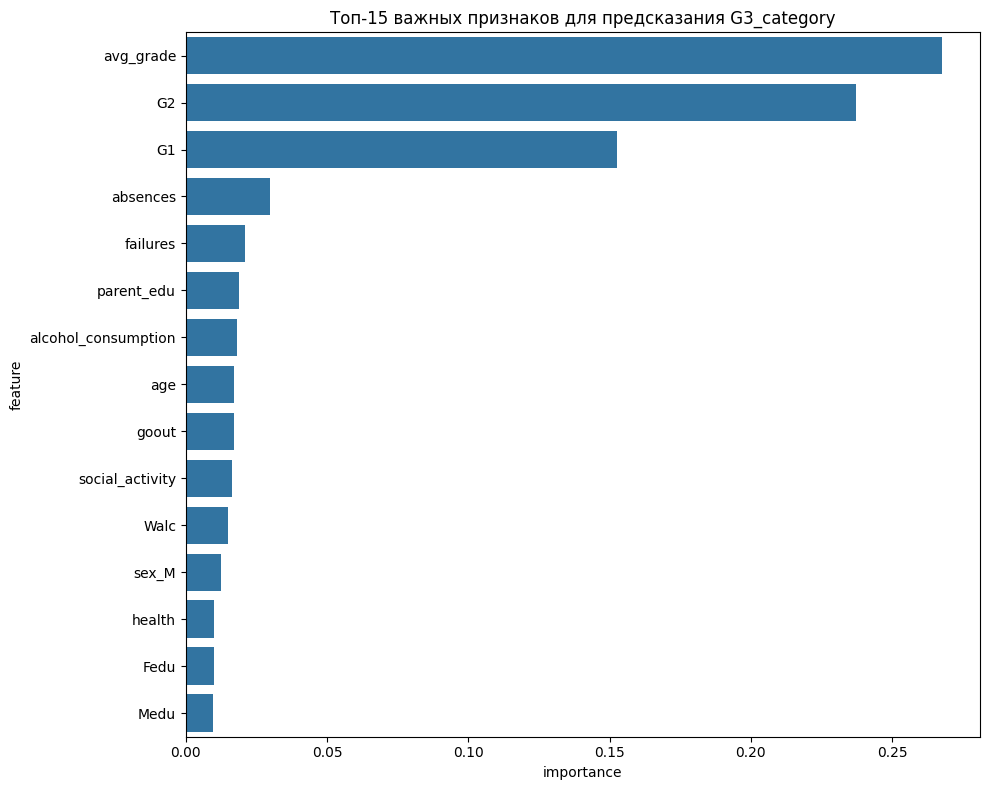

In [61]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# === Загрузка и очистка ===
df = pd.read_csv("student-mat.csv", sep=",")
df.columns = df.columns.str.strip()

# === Создание новых признаков ===
def create_new_features(df):
    df_copy = df.copy()
    df_copy['avg_grade'] = (df_copy['G1'] + df_copy['G2'] + df_copy['G3']) / 3
    df_copy['total_absences'] = df_copy['absences']
    df_copy['parent_edu'] = (df_copy['Medu'] + df_copy['Fedu']) / 2
    df_copy['alcohol_consumption'] = (df_copy['Dalc'] + df_copy['Walc']) / 2
    df_copy['social_activity'] = (df_copy['goout'] + df_copy['freetime']) / 2
    df_copy['has_school_support'] = (df_copy['schoolsup'] == 'yes').astype(int)
    df_copy['has_family_support'] = (df_copy['famsup'] == 'yes').astype(int)
    return df_copy

df_enhanced = create_new_features(df)

# === Категоризация G3 ===
def categorize_grade(g):
    if g < 10:
        return 'low'
    elif g < 15:
        return 'medium'
    else:
        return 'high'

df_enhanced['G3_category'] = df_enhanced['G3'].apply(categorize_grade)

# === Подготовка данных ===
def prepare_data_enhanced(df):
    df_processed = df.copy()

    feature_columns = [
        'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
        'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences',
        'G1', 'G2', 'avg_grade', 'parent_edu', 'alcohol_consumption',
        'social_activity', 'has_school_support', 'has_family_support'
    ]

    categorical_columns = ['school', 'sex', 'address', 'famsize', 'Pstatus',
                          'Mjob', 'Fjob', 'reason', 'guardian']

    encoder = OneHotEncoder(drop='first', sparse_output=False)
    encoded_features = encoder.fit_transform(df_processed[categorical_columns])
    encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))

    X_numerical = df_processed[feature_columns]
    X_combined = pd.concat([X_numerical.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

    y = df_processed['G3_category']

    return X_combined, y

X_enhanced, y_enhanced = prepare_data_enhanced(df_enhanced)

# === Разделение и балансировка ===
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced, y_enhanced, test_size=0.2, random_state=42, stratify=y_enhanced
)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_enh, y_train_enh)

# === Масштабирование ===
scaler_enh = StandardScaler()
X_train_scaled_enh = scaler_enh.fit_transform(X_train_balanced)
X_test_scaled_enh = scaler_enh.transform(X_test_enh)

# === Модель Random Forest ===
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_random = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("=== Обучение модели Random Forest (предсказание категорий G3) ===")
rf_random.fit(X_train_scaled_enh, y_train_balanced)

best_rf = rf_random.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled_enh)

# === Оценка ===
print(f"\nAccuracy: {accuracy_score(y_test_enh, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test_enh, y_pred_rf, average='weighted'):.4f}")
print("\nОтчёт по классификации:")
print(classification_report(y_test_enh, y_pred_rf))

# === Матрица ошибок ===
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_enh, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок - Классификация категорий G3')
plt.ylabel('Истинные категории')
plt.xlabel('Предсказанные категории')
plt.show()

# === Важность признаков ===
feature_importance = pd.DataFrame({
    'feature': X_enhanced.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Топ-15 важных признаков для предсказания G3_category')
plt.tight_layout()
plt.show()


Анализ метрик:

low (низкий балл)

15/15 предсказаны верно — 100% точность.
 Модель отлично определяет отстающих.

medium (средний балл)

Из 26 случаев: 24 верно, 2 перепутаны с “high”.
 Очень высокая точность, модель иногда «переоценивает» студентов среднего уровня.

high (высокий балл)

Из 38 примеров: 33 верно, 5 перепутаны (1 с “low”, 4 с “medium”).
 Большинство правильные, но есть лёгкое смещение в сторону более низких категорий — модель немного осторожна, склонна «недооценивать» лучших студентов.